# CLAMPS review bibliometric analysis — method walkthrough

This notebook is a step-by-step walkthrough of the method used to generate the **726 Works Collection** used in the paper. This is _not_ a reproduction of the full pipeline. Visit the repository (see `PIPELINE.md` and `OPERATIONS.md`) for complete pipeline documentation. 

**What Binder does:** replays saved pipeline outputs — it does *not* call OpenAlex or re-scan PDFs. Each phase below shows what the full pipeline does locally (see `PIPELINE.md` and `OPERATIONS.md`). This notebook uses those frozen checkpoints and regenerates the paper figures (~30 seconds on Binder).

| Phase | What happens |
|-------|--------------|
| **1** | OpenAlex discovery through eight channels (A–H) |
| **2** | Publication filters: topic exclusions → High Confidence gate → type filter |
| **3** | Parallel inclusion streams: datasets, ground-truth, theses |
| **4** | Merge streams → 726-work collection |
| **5** | Affiliation (NWC vs non-NWC) |
| **6** | Full-text impact funnel (PDF/HTML mention tiers) |
| **7** | Figures and summary tables |

In [4]:
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
for candidate in (ROOT, ROOT.parent, ROOT.parent / "bibliometrics"):
    if (candidate / "scripts").is_dir() and (candidate / "checkpoints").is_dir():
        ROOT = candidate
        break

os.environ["MPLCONFIGDIR"] = str(ROOT / ".matplotlib")
(ROOT / ".matplotlib").mkdir(exist_ok=True)
(ROOT / "output" / "figures").mkdir(parents=True, exist_ok=True)
(ROOT / "output" / "review_metrics").mkdir(parents=True, exist_ok=True)

if not (ROOT / "config.yaml").exists():
    import shutil
    shutil.copy(ROOT / "config.yaml.example", ROOT / "config.yaml")

sys.path.insert(0, str(ROOT))
print(f"Project root: {ROOT}")

Project root: /Users/elizabeth.smith/Documents/CLAMPSmiscdata/CLAMPSreview_biblio/bibliometrics


In [5]:
# Restore frozen checkpoints (Binder postBuild copies these to output/)
CHECKPOINTS = [
    "clamps_papers_high_confidence_channels_with_pdfs.csv",
    "clamps_papers_discovered_channels.csv",
    "clamps_data_deposits.csv",
    "clamps_theses_master_list.csv",
    "clamps_publications_html_scan_log.csv",
    "clamps_publications_html_mentions.csv",
    "clamps_scan_log.csv",
    "clamps_text_mentions.csv",
]
for name in CHECKPOINTS:
    src = ROOT / "checkpoints" / name
    dst = ROOT / "output" / name
    if src.exists() and (not dst.exists() or dst.stat().st_size == 0):
        dst.write_bytes(src.read_bytes())

local_log = ROOT / "output" / "clamps_local_scan_log.csv"
if not local_log.exists() or local_log.stat().st_size == 0:
    local_log.write_text(
        "openalex_id,doi,status,mention_count,matched_terms,match_strength,error\n"
    )
print("Checkpoints ready.")

Checkpoints ready.


---
## Phase 1 — OpenAlex multi-channel discovery

The full pipeline queries OpenAlex through **eight discovery channels**. Works can appear
in multiple channels; the merged ledger deduplicates by DOI / OpenAlex ID.

| Channel | Role |
|---------|------|
| **A** | Facility identity phrases (CLAMPS, Mobile PISA, …) |
| **B** | Campaign × instrument compound queries |
| **C** | Dataset DOI and grant citations |
| **D** | Author seed bibliographies |
| **E** | Campaign anchor-paper author groups |
| **F** | OpenAlex thesis institutions |
| **G** | Ground-truth DOI registry (mandatory bypass) |
| **H** | Institutional repository thesis crawl |

Locally: `python scripts/discover_channels.py` (+ thesis discovery scripts).
On Binder: replay `clamps_papers_discovered_channels.csv`.

- Channel A uses specifically chosen terms that reflect different ways the CLAMPS facilities may be identified. For example we search for "CLAMPS 1" and "CLAMPS-1" phrases. There are some other terms included here as well (e.g., "NSSL Mobile Profiling" and "Mobile PISA")
- Channdel B builds compound queries based on a list of field campaign names and a set of keywords intended to identify works that include the observation data CLAMPS produces from campaigns CLAMPS was on. The keywords include some contextual terms like "retreival" and some specific ones like "AERI"
- Channel C is based on a provided list of dataset DOIs and grant numbers. We discover works that directly cite or otherwise reference these
- Channel D searches for works authored by an author group that includes CLAMPS operators, common collaborators, and frequent data users. It is highly likely that many or even most of these entries are not CLAMPS related. Relevance scoring and filtering should address this later on
- Channel E works in the same way as channel D except the author pool comprises the authors of campaign overview papers (e.g., Geerts et al. 2017, PECAN)
- Channel F searches for theses and dissertations from a provided list of institutions. We chose to include core US institutions with advanced degree offerings in meteorology or atmospheric science, international universities active in meteorology (or related) research, and any additional universities that are home to campaign partners. Any omissions are not intentional
- Channel G is a collection of known CLAMPS-related publications. These are guaranteed to be included in the final collection, and they serve as good validation. Channels A-F should have identified 100% of these entries. If not, query strategy needs adjusting.
- Channel H is an additional search for theses and dissertations. The OpenAlex discovery is not always able to access institutional repositories. This step directly targets the repositories of the same list of institurions used in channel F. 

### Metadata relevance scoring

Every discovered work is scored at ingest time (`clamps_biblio/relevance.py`) using a **`relevance_score`** 

**Relevance Scoring**:
Each discovered work gets a summed score based on all the signals it hits. 
| Signal | Points |
|--------|--------|
| Channel C (dataset DOI / grant citation) | +6 |
| Channel A, B, F, H discovery source | +5 |
| Channel D, E, G discovery source | +4 |
| CLAMPS facility phrase in metadata (e.g., title, abstract, etc.)  | +4 |
| CLAMPS signal present (channel-specific bonus) | +2 |
| Channel B: campaign + observational vocabulary | +1 to +2 |
| Meteorology topic keyword in title/topics | +1 |
| Relevant institution (NSSL, CIMMS, NOAA, …) | +1 |
| Campaign name only — no CLAMPS evidence | −4 |
| Known false-positive title (medical “clamp”, DNA, …) | −4 |
| Generic search hit without CLAMPS or NSSL data URL | −3 |
| Channel H: campaign-candidate thesis (no CLAMPS phrase) | −2 |

**Confidence Tiers**:
The summed relvance score is mapped to a **`confidence_tier`**.
| Tier | Score | Meaning |
|------|-------|---------|
| **high** | ≥ 6 | Strong CLAMPS + channel evidence in metadata |
| **medium** | 3–5 | Partial evidence; may need channel-specific confirmation |
| **low** | < 3 | Weak or ambiguous hit |

Phase 2 applies **additional channel-specific rules** on top of these tiers; not every high-tier work enters the publication pool).

In [6]:
from clamps_biblio.corpus_ledger import discovery_channel_counts, discovery_confidence_distribution

channels = discovery_channel_counts(ROOT)
if channels.empty:
    print("No discovery checkpoint — run full pipeline locally.")
else:
    display(Markdown("**Channel hits** (overlapping — same work may appear in multiple channels)"))
    display(channels[["label", "works"]].rename(columns={"label": "channel", "works": "hits"}))
    total_hits = int(channels["works"].sum())
    merged = len(pd.read_csv(ROOT / "output" / "clamps_papers_discovered_channels.csv"))
    print(f"\nRaw channel hits (overlapping): {total_hits:,}")
    print(f"Merged discovery ledger (unique works): {merged:,}")

    display(Markdown("**Confidence tiers** assigned by metadata relevance scoring"))
    display(discovery_confidence_distribution(ROOT))

    disc = pd.read_csv(ROOT / "output" / "clamps_papers_discovered_channels.csv")
    if "relevance_score" in disc.columns:
        summary = disc.groupby("confidence_tier")["relevance_score"].agg(["min", "median", "max"]).round(0)
        display(Markdown("**Score range by tier** (checkpoint values)"))
        display(summary.rename(columns={"min": "min_score", "median": "median_score", "max": "max_score"}))

**Channel hits** (overlapping — same work may appear in multiple channels)

,channel,hits
0,A — Facility identity phrases,602
1,B — Campaign × instrument compound queries,833
2,C — Dataset DOI & grant citations,5
3,D — Author seed bibliographies,1065
4,E — Campaign anchor-paper author groups,1631
5,G — Ground-truth DOI registry,132
6,H — Institutional repository thesis crawl,1940



Raw channel hits (overlapping): 6,208
Merged discovery ledger (unique works): 6,208


**Confidence tiers** assigned by metadata relevance scoring

,tier,works,score_range
0,high,1587,score ≥ 6
1,medium,4403,score 3–5
2,low,218,score < 3


**Score range by tier** (checkpoint values)

,min_score,median_score,max_score
confidence_tier,,,
high,6,6.0,13
low,-1,1.0,2
medium,3,4.0,5


---
## Phase 2 — How scoring is used: publication filters

Phase 1 assigns every work a `confidence_tier`. Phase 2 decides which works enter the
**High-confidence (HC) publication stream** using that tier plus channel-specific rules.

**Filter sequence:**

1. **Topic exclusions** — remove non-meteorology false positives (independent of score)
2. **Tier floor** — drop `low` tier (score < 3); only `medium` and `high` continue
3. **Strict HC gate** — channel-specific CLAMPS evidence rules (see below)
4. **HC checkpoint export** — curated publication pool written to disk
5. **Type filter** — keep only works labeled as articles, preprints, reviews, reports at merge

**Strict HC gate rules** (`qualifies_strict_high_confidence`):

| Channel | Rule |
|---------|------|
| **C, G** | Auto-pass (dataset citation or ground-truth registry) |
| **B** | Pass if compound query is unambiguous; ambiguous campaign hits (e.g., SCALES vs the word 'scales') need CLAMPS phrase in metadata |
| **A** | Pass if facility identity phrase matches |
| **F, H** | Pass only if CLAMPS phrase or NSSL data access info in metadata |
| **D, E** | Pass if CLAMPS phrase or NSSL data URL in metadata |

The funnel table shows how many works survive each step. The channel table shows
what fraction of medium/high-tier works pass the strict gate by channel.

In [7]:
from clamps_biblio.corpus_ledger import publication_filter_funnel, strict_gate_by_channel

display(Markdown("**Publication filter funnel** — how Phase 1 scores are applied"))
display(publication_filter_funnel(ROOT))

display(Markdown("**Strict HC gate pass rate by channel** (medium/high tier works only)"))
gate = strict_gate_by_channel(ROOT)
if gate.empty:
    print("No discovery checkpoint available.")
else:
    display(gate)

**Publication filter funnel** — how Phase 1 scores are applied

,step,works,notes
0,1. Merged discovery ledger,6208,Unique works after channel merge; each has rel...
1,2. Topic exclusions removed,5994,214 works flagged (non-meteorology / literary ...
2,3. Low-confidence tier removed,5787,207 low-tier works dropped (score < 3); gate r...
3,4. Strict HC gate (channel rules),744,Medium/high tier plus channel-specific CLAMPS ...
4,5. HC publication checkpoint,563,Curated pool after strict gate + pipeline expo...
5,6. Publication type filter,520,"Articles, preprints, reviews, reports — exclud..."


**Strict HC gate pass rate by channel** (medium/high tier works only)

,channel,eligible_medium_high,pass_strict_gate,pct_pass
6,H — Institutional repository thesis crawl,1905,0,0.0
4,E — Campaign anchor-paper author groups,1514,0,0.0
3,D — Author seed bibliographies,940,0,0.0
1,B — Campaign × instrument compound queries,759,593,78.1
0,A — Facility identity phrases,576,58,10.1
5,G — Ground-truth DOI registry,88,88,100.0
2,C — Dataset DOI & grant citations,5,5,100.0


---
## Phase 3 — Parallel inclusion streams

The final collection of works is a merge of **four independent streams**. Streams overlap (e.g. a ground-truth DOI may also appear in the HC pool); overlaps are removed at merge time.

| Stream | Source | What it adds |
|--------|--------|--------------|
| **HC publications** | Phase 2 output | Peer-reviewed and grey literature |
| **Validated datasets** | Seed registry + discovered deposits | 107 records|
| **Ground-truth mandatory** | Channel G registry | Works that must be included regardless of filters |
| **Manual theses** | Channel H/F crawl | Discovered theses manually flagged for inclusion or exclusion |

In [8]:
from clamps_biblio.corpus_ledger import inclusion_stream_counts

streams = inclusion_stream_counts(ROOT)
display(streams[["stream", "works", "description"]])
if not streams.empty:
    print(f"\nPre-deduplication stream total (overlapping): {int(streams['works'].sum()):,}")

,stream,works,description
0,HC publications,563,Articles/reports after discovery gate and type...
1,Validated datasets,107,work_class=x deposits (65 seed + 42 discovered)
2,Manual theses,28,Channel H/F theses with manual_flag=y
3,Ground-truth mandatory,132,Registry bypass (Channel G); overlaps other st...



Pre-deduplication stream total (overlapping): 830


---
## Phase 4 — Build the 726-work collection

`build_review_corpus.py` merges the four streams, deduplicates, and writes
`clamps_review_corpus.csv`, including campaign labels and work-type tags.

**Expected result:** 726 unique works = 590 published literature + 107 datasets + 29 theses
(with overlaps removed across streams).

> **Note:** Phase 2 step 5 yields ~520 works from the HC publication pool alone. The final 
> **590 published literature** count also includes articles/reports admitted via the
> other channels with high-confidence.

In [9]:
def run(script: str, *args: str) -> None:
    cmd = [sys.executable, str(ROOT / "scripts" / script), *args]
    print(f"\n>>> {' '.join(cmd)}")
    subprocess.run(cmd, check=True, cwd=ROOT)

run("ensure_mandatory_corpus_inputs.py")
run("build_review_corpus.py")
run("export_review_corpus_clean.py")


>>> /Users/elizabeth.smith/miniforge3/bin/python3.13 /Users/elizabeth.smith/Documents/CLAMPSmiscdata/CLAMPSreview_biblio/bibliometrics/scripts/ensure_mandatory_corpus_inputs.py
Seed DOIs listed: 65
Deposits rows: 265 (work_class=x: 107)
Promoted existing rows to x: 0
Added from OpenAlex: 0
Stubbed (no OpenAlex metadata): 0

>>> /Users/elizabeth.smith/miniforge3/bin/python3.13 /Users/elizabeth.smith/Documents/CLAMPSmiscdata/CLAMPSreview_biblio/bibliometrics/scripts/build_review_corpus.py
Wrote 726 works -> /Users/elizabeth.smith/Documents/CLAMPSmiscdata/CLAMPSreview_biblio/bibliometrics/output/clamps_review_corpus.csv

By corpus_class:
corpus_class
article    570
dataset    107
report      20
thesis      29

By corpus_source:
corpus_source
data_deposits             107
ground_truth_mandatory     72
hc_publications           519
theses_master              28

Deduped 61 duplicate work_key(s) across sources.

Ground-truth mandatory rows in corpus: 72

>>> /Users/elizabeth.smith/miniforge

In [10]:
from clamps_biblio.corpus_ledger import corpus_composition, merge_stream_counts

corpus = pd.read_csv(ROOT / "output" / "clamps_review_corpus_clean.csv")
print(f"Final collection: {len(corpus)} works\n")
display(corpus_composition(ROOT))

final = merge_stream_counts(ROOT)
final_row = final[final["stream"].astype(str).str.startswith("Final collection")]
if not final_row.empty:
    print(f"\nDeduplicated total: {int(final_row.iloc[0]['works'])} works")

if len(corpus) != 726:
    raise RuntimeError(f"Expected 726 works, got {len(corpus)}")

Final corpus: 726 works



,work_type,count
0,Article,570
1,Dataset,107
2,Report,20
3,Thesis,29



Deduplicated total: 726 works


---
## Phase 5 — Affiliation

Affiliation (defined as NWC-affiliated or non-NWC-affiliated) inferred from OpenAlex co-author institutions (plus manual overrides in `data/affiliation_overrides.csv` where the search failed to identify affiliation). 

This table summarizes the **final collection** by inclusion type.

In [12]:
from clamps_biblio.review_metrics_data import load_corpus_review_frames
from clamps_biblio.nwc_affiliation import NWC_AFFILIATED, NON_AFFILIATED

frames = load_corpus_review_frames(ROOT)
all_works = frames["flagged_yd"]
pubs = frames["pdf_confirmed"]
theses = all_works[all_works["corpus_class"] == "thesis"]

def affil_row(df, label):
    return {
        "subset": label,
        "total": len(df),
        "NWC": int((df["affiliation"] == NWC_AFFILIATED).sum()),
        "Non-NWC": int((df["affiliation"] == NON_AFFILIATED).sum()),
    }

display(pd.DataFrame([
    affil_row(all_works, "Full review collection (726)"),
    affil_row(pubs, "Published literature (590)"),
    affil_row(theses, "Theses (29)"),
]))

,subset,total,NWC,Non-NWC
0,Full review corpus (726),726,166,560
1,Published literature (590),590,107,483
2,Theses (29),29,19,10


---
## Phase 6 — Full-text scan

For the **590 published-literature works**, the pipeline can optionally scan PDFs and publisher HTML for CLAMPS mentions, then classifies each hit by substantive use (Tier 1–2) vs peripheral reference (Tier 3).

```
590 published literature
 └─ 54 with full-text CLAMPS mention
     └─ 21 substantive use (Tier 1+2)
     └─ 33 peripheral (Tier 3)
 └─ 569 not classified
```
This step does not add or remove works; it classifies works already discovered. Many works are discoverable via abstract/title/channel logic; fewer show substantive CLAMPS use in methods/result, which is important for understanding how CLAMPS impacts the community. 

- 590 — all published literature in the final pool
- 54 — subset where a scan found full, explicit CLAMPS text 
- 21 — subset where the mention looks like data/analysis/discussion (Tier 1–2), not just a passing reference (Tier 3)

The other 569 are still in the pool. They were admitted on metadata, but either:
 - no PDF/HTML resolved or able to be scanned
 - the full text was scanned and no additional CLAMPS mention was found

In [14]:
from clamps_biblio.corpus_ledger import fulltext_impact_funnel

display(fulltext_impact_funnel(ROOT))

,step,works,notes
0,Published literature in corpus,590,"Articles, reports, and preprints (590 of 726 t..."
1,Full-text CLAMPS mention found,54,PDF/HTML scan produced CLAMPS mention snippets
2,Substantive use (Tier 1+2),21,"Classified as data, analysis, or discussion — ..."


---
## Phase 7 — Figures and summary tables

Regenerate paper figures from final dataset built above. Summary tables reflect outcomes from Phases 4–6.

In [15]:
run("plot_review_figures.py", "--no-archive")
print("Figures written to output/figures/")


>>> /Users/elizabeth.smith/miniforge3/bin/python3.13 /Users/elizabeth.smith/Documents/CLAMPSmiscdata/CLAMPSreview_biblio/bibliometrics/scripts/plot_review_figures.py --no-archive
Using review corpus: 726 all works, 590 published literature (article+report)
Figures and tables written to /Users/elizabeth.smith/Documents/CLAMPSmiscdata/CLAMPSreview_biblio/bibliometrics/output/figures/
  fig_affiliation_by_year.png/pdf
  fig_affiliation_by_year_with_deployments.png/pdf
  fig_work_type_by_year_with_deployments.png/pdf
  ../review_metrics/list_unknown_affiliation.csv
  table_corpus_summary.csv / .tex
  table_impact_summary.csv / .tex
  fig_campaign_by_year.png/pdf
Figures written to output/figures/


### `fig_affiliation_by_year_with_deployments.png`

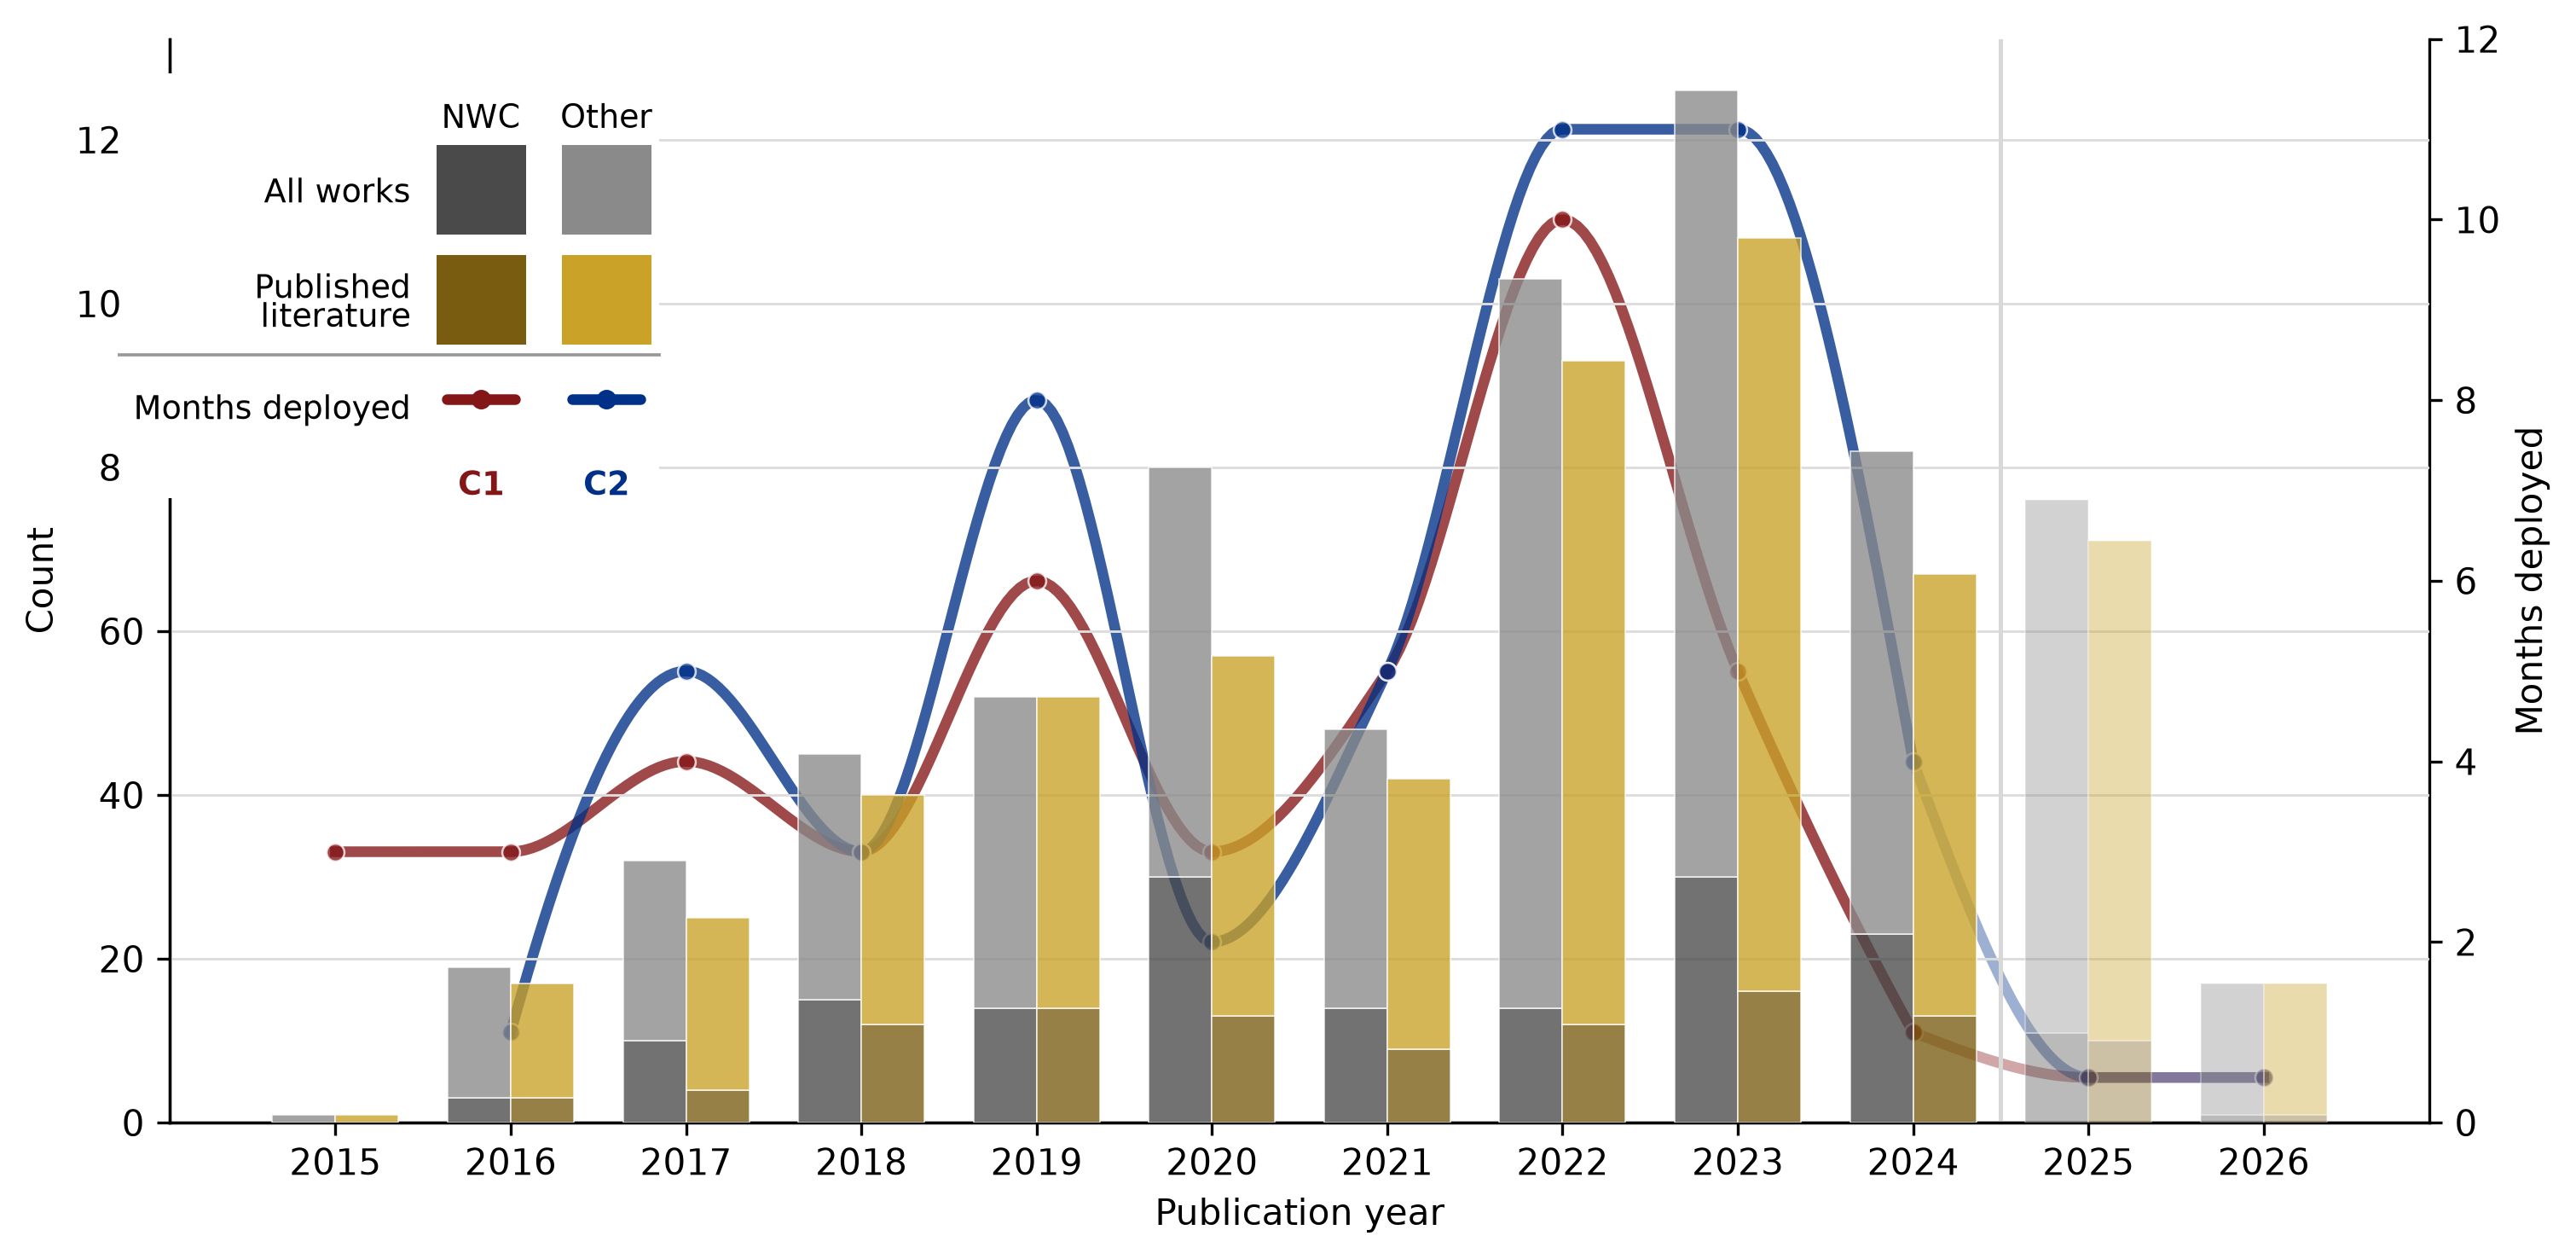

### `fig_work_type_by_year_with_deployments.png`

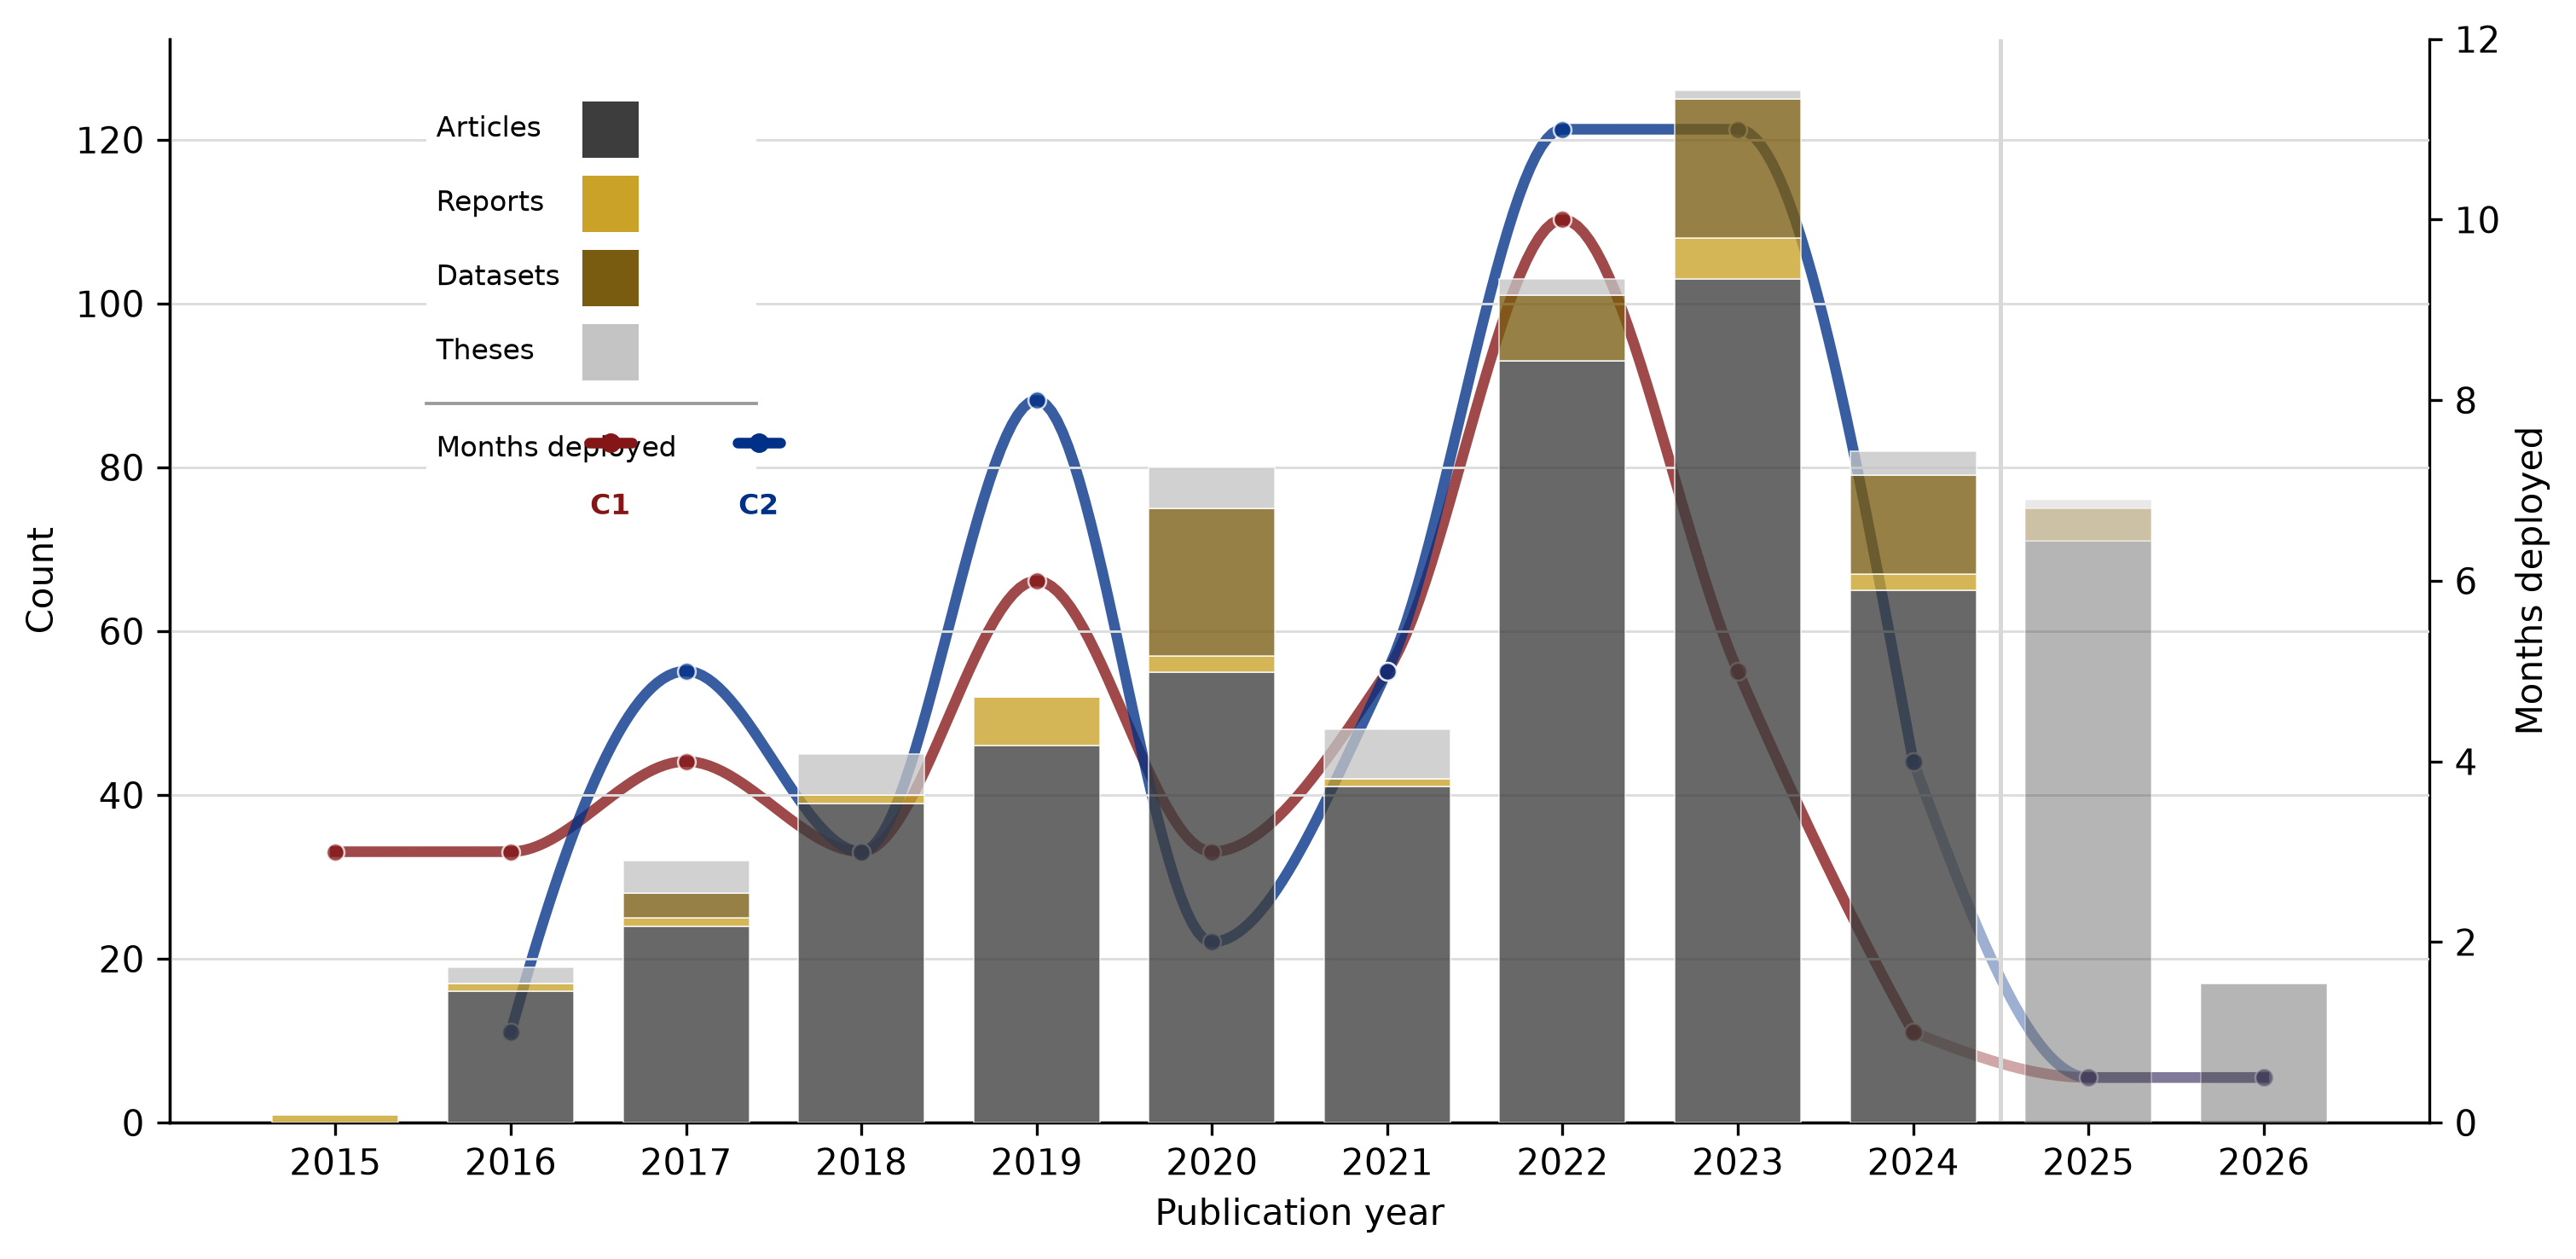

### `fig_campaign_by_year.png`

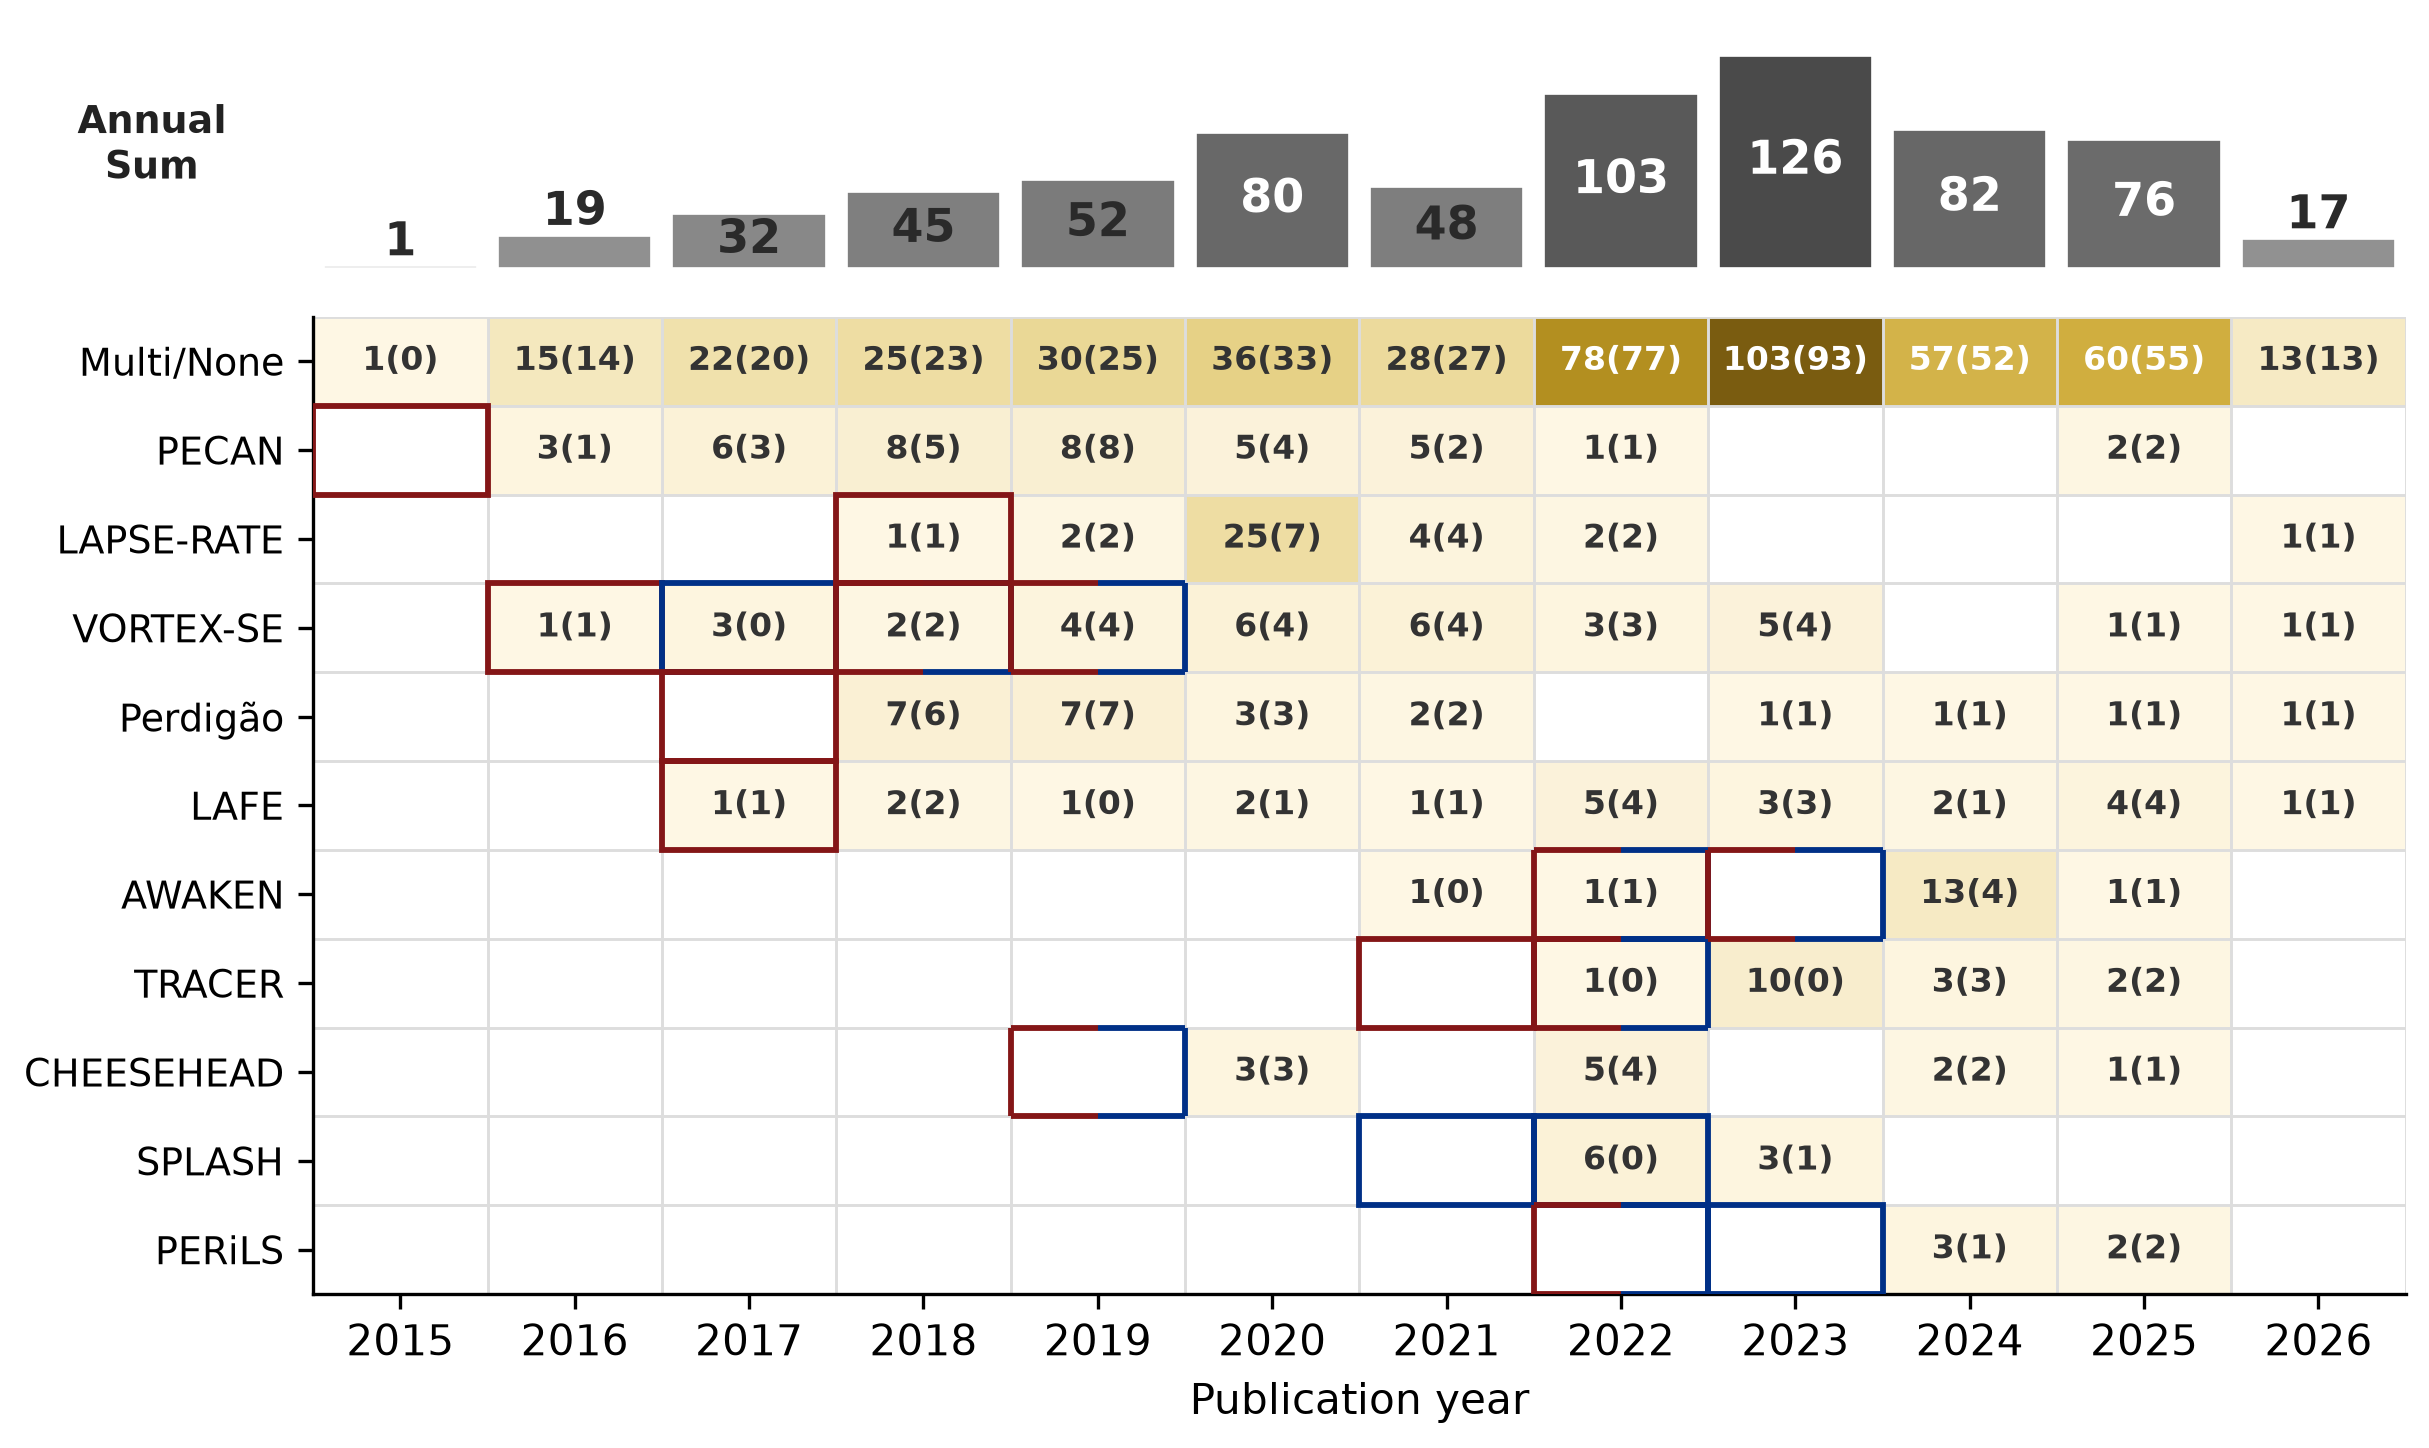

**Corpus summary** — final corpus by inclusion type (Phase 4–5)

,metric,notes,NWC,Non-NWC,total
0,Full review corpus,726 works; all inclusion streams,166.0,560.0,726
1,Published literature,"Articles, reports, and preprints (590 works)",107.0,483.0,590
2,Theses & dissertations,Manual acceptance via Channel H/F,19.0,10.0,29
3,All datasets,107 validated deposits; affiliation not applied,NaN,NaN,107


**Impact summary** — full-text funnel for published literature (Phase 6)

,step,works,NWC,Non-NWC,notes
0,Published literature (review corpus),590,107,483,"Baseline: all articles, reports, and preprints..."
1,Full-text CLAMPS mention found,54,6,48,Subset of published literature with PDF/HTML s...
2,Substantive use (Tier 1+2),21,3,18,"Data, analysis, or discussion use — excludes p..."
3,Theses (review corpus),29,19,10,29 manual theses; full-text scan coverage is l...


In [16]:
fig_dir = ROOT / "output" / "figures"
for name in [
    "fig_affiliation_by_year_with_deployments.png",
    "fig_work_type_by_year_with_deployments.png",
    "fig_campaign_by_year.png",
]:
    path = fig_dir / name
    if path.exists():
        display(Markdown(f"### `{name}`"))
        display(Image(filename=str(path)))

display(Markdown("**Collection summary** — final collection by inclusion type (Phase 4–5)"))
display(pd.read_csv(fig_dir / "table_corpus_summary.csv").rename(columns={
    "nwc_affiliated": "NWC", "non_affiliated": "Non-NWC",
}))

display(Markdown("**Impact summary** — full-text funnel for published literature (Phase 6)"))
display(pd.read_csv(fig_dir / "table_impact_summary.csv").rename(columns={
    "impact_metric": "step",
    "count": "works",
    "nwc_affiliated": "NWC",
    "non_affiliated": "Non-NWC",
})[["step", "works", "NWC", "Non-NWC", "notes"]])

---
## Next steps

### Run the full pipeline on your own machine
Download this repository and follow **`OPERATIONS.md`** to adapt discovery channels,
ground-truth registries, and affiliation rules for another facility.

### Cite this work
Use the Zenodo DOI from **`CITATION.cff`** once published. See **`ZENODO.md`** for upload steps.

### Check out the Case Gallery 
A suite of example cases and an example of data visualization code are hosted in the Case Gallery repository with its own Binder notebook.